In [2]:
import pandas as pd
from IPython.display import display, Markdown
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import dash
from dash import html, dcc
from dash.dependencies import Output, Input, State
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier


df_original = pd.read_csv("data/commercial_planning.csv", encoding="latin-1")

display(Markdown("### Estructura y consistencia de los datos"))
display(df_original.info())

final_states = ["CLOSED", "COMPLETE", "CANCELED", "SUSPECTED_FRAUD"]
df_original = df_original[df_original["Order Status"].isin(final_states)]
df_original["Order Success"] = df_original["Order Status"].isin(["COMPLETE", "CLOSED"]).astype(int)

display(Markdown(f"### Creación de la variable Target 'Order Success': {df_original["Order Success"].unique()}"))

### Estructura y consistencia de los datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Days for shipment (scheduled)  180519 non-null  int64  
 1   Category Name                  180519 non-null  object 
 2   Market                         180519 non-null  object 
 3   Order Item Discount            180519 non-null  float64
 4   Order Item Profit Ratio        180519 non-null  float64
 5   Order Region                   180519 non-null  object 
 6   Order Status                   180519 non-null  object 
 7   Product Price                  180519 non-null  float64
 8   Shipping Mode                  180519 non-null  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 12.4+ MB


None

### Creación de la variable Target 'Order Success': [1 0]

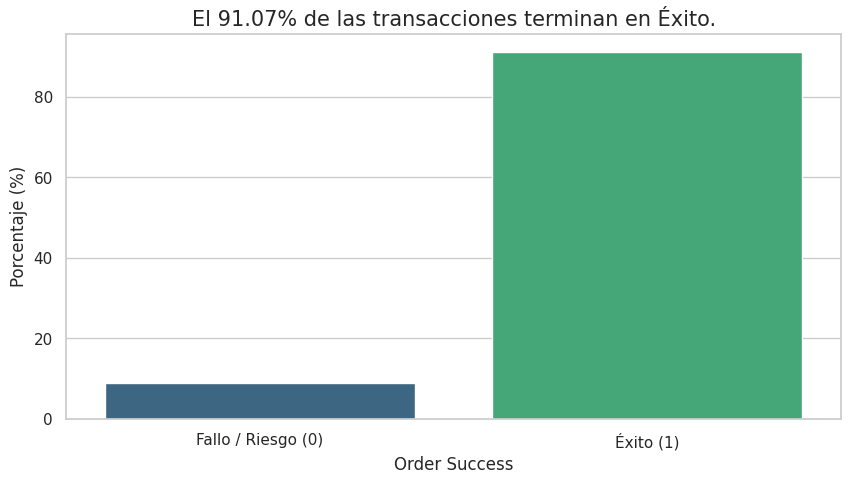

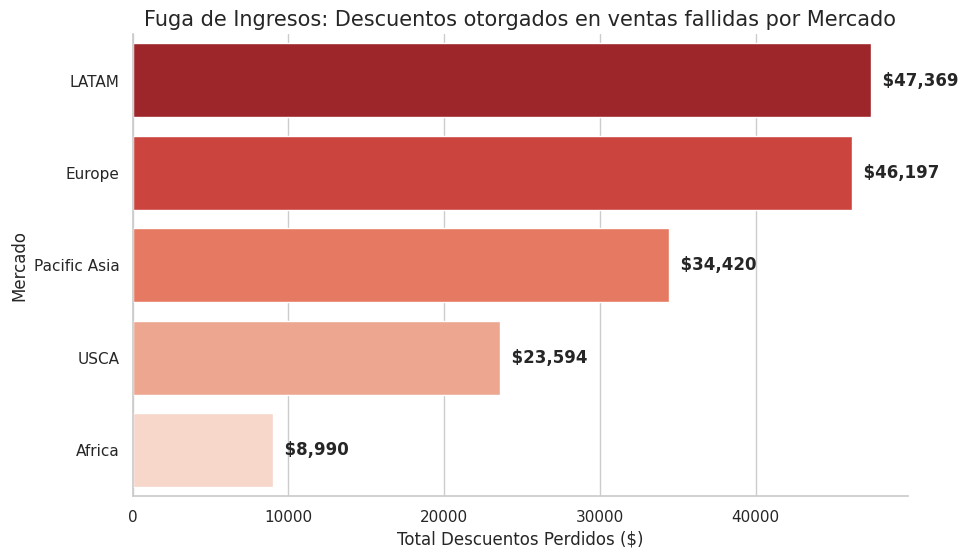

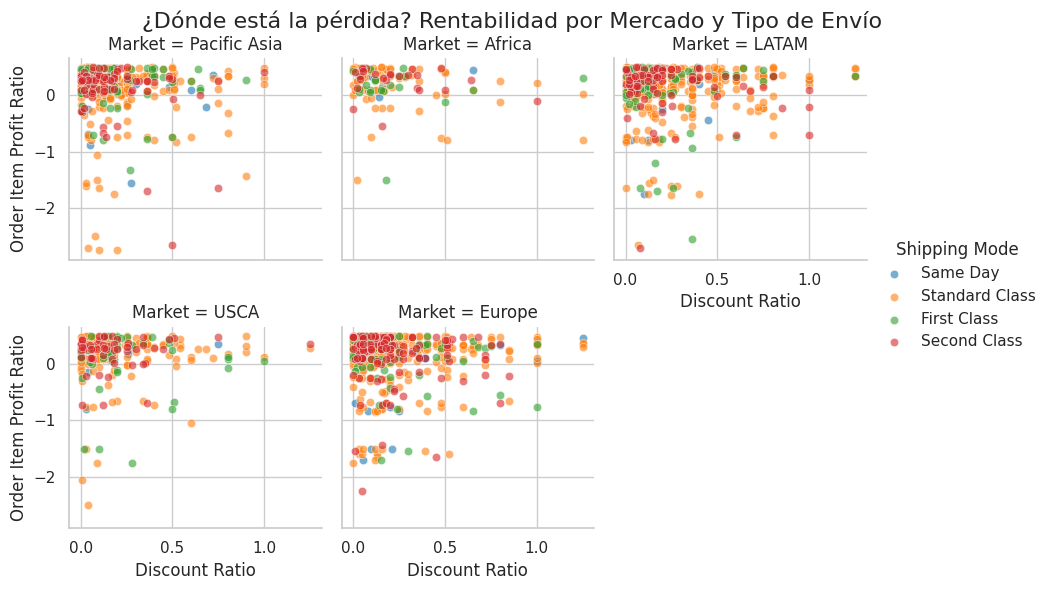

In [3]:
df_original["Discount Ratio"] = df_original["Order Item Discount"] / df_original["Product Price"]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [12, 6]

success_counts = df_original["Order Success"].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=success_counts.index, y=success_counts.values, palette="viridis", hue=success_counts.index, legend=False)
plt.title(f"El {success_counts[1]:.2f}% de las transacciones terminan en Éxito.", fontsize=15)
plt.ylabel("Porcentaje (%)")
plt.xticks([0, 1], ["Fallo / Riesgo (0)", "Éxito (1)"])
plt.show()

lost_status = ["CANCELED", "SUSPECTED_FRAUD"]
df_lost = df_original[df_original["Order Status"].isin(lost_status)].copy()
discount_lost = df_lost.groupby("Market")["Order Item Discount"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=discount_lost, x="Order Item Discount", y="Market", hue="Market", palette="Reds_r", legend=False)

for i, valor in enumerate(discount_lost["Order Item Discount"]):
    plt.text(valor, i, f'  ${valor:,.0f}', va="center", fontweight="bold")

plt.title("Fuga de Ingresos: Descuentos otorgados en ventas fallidas por Mercado", fontsize=15)
plt.xlabel("Total Descuentos Perdidos ($)")
plt.ylabel("Mercado")
sns.despine()
plt.show()

grid = sns.FacetGrid(df_original.sample(min(2000, len(df_original))), col="Market", hue="Shipping Mode", palette="tab10", col_wrap=3)
grid.map(sns.scatterplot, "Discount Ratio", "Order Item Profit Ratio", alpha=0.6)
grid.add_legend()
grid.fig.subplots_adjust(top=0.9)
grid.fig.suptitle("¿Dónde está la pérdida? Rentabilidad por Mercado y Tipo de Envío", fontsize=16)
plt.show()

#### Feature Engineering: estandarización y codificación
Este enfoque de preprocesamiento de datos se basa en un enfoque dual diseñado para optimizar el rendimiento y la estabilidad del modelo. Al combinar ambas técnicas logramos un balance óptimo, ya que trabajan en conjuntos de datos separados (categóricos vs. numéricos) para preparar un conjunto final altamente informativo, limpio y computacionalmente eficiente.


In [4]:
df = df_original.copy()
df.drop(columns=["Order Status","Order Item Discount"], inplace=True)
df = df.reset_index(drop=True)

categorical_vars = ["Category Name", "Market", "Order Region", "Shipping Mode"]
numeric_vars = ["Days for shipment (scheduled)", "Product Price", "Discount Ratio"]

scaler = StandardScaler()
df[numeric_vars] = scaler.fit_transform(df[numeric_vars])

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
encoder.fit(df[categorical_vars])
df[categorical_vars] = encoder.transform(df[categorical_vars])

column = df.pop("Order Success")
df.insert(0, "Order Success", column)

display(Markdown("### Dataset pre-procesado"))
display(df)

### Dataset pre-procesado

,Order Success,Days for shipment (scheduled),Category Name,Market,Order Item Profit Ratio,Order Region,Product Price,Shipping Mode,Discount Ratio
0,1,0.781168,40.0,3.0,0.29,15.0,1.323239,3.0,-0.752237
1,1,0.781168,40.0,3.0,-0.80,13.0,1.323239,3.0,-0.688079
2,1,0.781168,40.0,3.0,0.08,11.0,1.323239,3.0,-0.624051
3,0,0.781168,40.0,3.0,0.06,11.0,1.323239,3.0,-0.495734
4,1,-1.394981,40.0,3.0,0.33,7.0,1.323239,0.0,-0.410320
...,...,...,...,...,...,...,...,...,...
86856,1,0.781168,18.0,3.0,0.31,7.0,1.835549,3.0,-0.495778
86857,1,-0.669598,18.0,3.0,0.25,7.0,1.835549,2.0,-0.282069
86858,1,0.781168,18.0,3.0,0.27,7.0,1.835549,3.0,-0.068360
86859,1,0.781168,18.0,3.0,0.10,7.0,1.835549,3.0,-0.923196


#### Bagging (K-Neighbors): reforzando los casos más cercanos
Es una de las principales técnicas computacionales de estadística inferencial cuya objetivo se basa en eliminar o reducir lo máximo posible la varianza en los resultados, su método es utilizar la sabiduría de las masas, es decir, reforzar el aprendizaje mediante el criterio de distintos metaestimadores que se encargarán de sacar sus propias conclusiones de respectivos datos seleccionados para luego, dependiendo del problema en cuestión, llegar a una respuesta final a través de la media o moda del conjunto de resultados. Al entrenar múltiples modelos con datos ligeramente distintos y contar sus resultados, el Bagging suaviza estas fluctuaciones. La agregación de los resultados cancela la varianza individual de cada modelo, resultando en un modelo de conjunto con un error de varianza significativamente menor.

In [9]:
X_train_columns = categorical_vars + numeric_vars
X_train_data = df[X_train_columns]

knn_classifier = KNeighborsClassifier(n_neighbors=5)

bagging_knn = BaggingClassifier(estimator=knn_classifier,
                                n_estimators=100,
                                max_samples=0.3,
                                bootstrap=True)

bagging_knn.fit(df[X_train_columns], df["Order Success"])

new_object = df_original.sample(n=1)
new_object.drop(columns=["Order Status","Order Item Discount"], inplace=True)
new_object = new_object.reset_index(drop=True)

obj_num_scaled = scaler.transform(new_object[numeric_vars])
df_obj_num = pd.DataFrame(obj_num_scaled, columns=numeric_vars, index=new_object.index)

obj_cat_encoded = encoder.transform(new_object[categorical_vars])
df_obj_cat = pd.DataFrame(obj_cat_encoded, columns=encoder.get_feature_names_out(categorical_vars), index=new_object.index)

object_processed = pd.concat([df_obj_num, df_obj_cat], axis=1)
object_processed = object_processed[X_train_columns]

predict_proba = bagging_knn.predict_proba(object_processed)
riesgo_fracaso = predict_proba[0, 0] * 100

display(Markdown("### Nueva planificación comercial (ejemplo)"))
print("-" * 40)
display(Markdown(f"### Riesgo de fracaso: {riesgo_fracaso:.2f}%"))

### Nueva planificación comercial (ejemplo)

----------------------------------------


### Riesgo de fracaso: 18.00%

#### Herramienta interactiva basada en un socring de riesgo en la ejecución de nuevas planficaciones comerciales

In [ ]:
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_train_data)

df_pca = pd.DataFrame(pca_results, columns=["PC1", "PC2"])
df_pca["Order Success"] = df["Order Success"].values

success = df_pca.loc[df_pca["Order Success"] == 1,:]
fails = df_pca.loc[df_pca["Order Success"] == 0,:]

probability_text = html.B(id="probability",children=[],style={})

fig_pca = go.Figure()
fig_pca.add_trace(go.Scatter(x=success["PC1"], y=success["PC2"], mode="markers", marker_color="green", name="Completadas"))
fig_pca.add_trace(go.Scatter(x=fails["PC1"], y=fails["PC2"], mode="markers", marker_color="red", name="Sin éxito"))
fig_pca.update_layout(title="Resultados de órdenes históricas")
fig_pca.update_layout(legend=dict(font=dict(size=9)))

app = dash.Dash(__name__)

app.layout =  html.Div(id="body",className="e4_body",children=[
    html.H1("Evaluación en riesgo de venta de nuevos productos",id="title",className="e4_title"),
    html.Div(id="dashboard",className="e4_dashboard",children=[
        html.Div(className="e4_graph_div",children=[
            dcc.Graph(id="graph_pca", className="e4_graph", figure=fig_pca),
            html.Div(id="input_div", style={"display":"flex","flexWrap":"wrap","gap":"10px"}, children=[
                dcc.Input(id="input_1", type="number", placeholder="Días envío", style={"width":"75px"}),
                dcc.Input(id="input_5", type="number", placeholder="Precio Producto", style={"width":"75px"}),
                dcc.Input(id="input_6", type="number", placeholder="Ratio Descuento", style={"width":"75px"}),
                dcc.Dropdown(id="input_2", options=df_original["Market"].unique(), placeholder="Mercado", style={"width":"150px"}),
                dcc.Dropdown(id="input_3", options=df_original["Order Region"].unique(), placeholder="Región", style={"width":"150px"}),
                dcc.Dropdown(id="input_4", options=df_original["Category Name"].unique(), placeholder="Categoría", style={"width":"150px"}),
                dcc.Dropdown(id="input_7", options=df_original["Shipping Mode"].unique(), placeholder="Tipo Envío", style={"width":"150px"}),
                html.Button(id="button", className="e4_button", children="Enviar", n_clicks=0)
            ]),
            html.P(["predicción: riesgo de fracaso de ",probability_text,"%"],className="e4_predict")
        ])
    ])
])

@app.callback(
    [Output(component_id="graph_pca",component_property="figure"),
    Output(component_id="probability",component_property="children"),
    Output(component_id="probability",component_property="style")],
    [Input(component_id="button",component_property="n_clicks")],
    [State(component_id="input_1",component_property="value"),
    State(component_id="input_2",component_property="value"),
    State(component_id="input_3",component_property="value"),
    State(component_id="input_4",component_property="value"),
    State(component_id="input_5",component_property="value"),
    State(component_id="input_6",component_property="value"),
    State(component_id="input_7",component_property="value")]
)

def get_risk_prob(n_clicks, var_1, var_2, var_3, var_4, var_5, var_6, var_7):
    fig_update = go.Figure(fig_pca)
    prob_fail_text = "0.00%"
    style_res = {"color": "black"}

    inputs = [var_1, var_2, var_3, var_4, var_5, var_6, var_7]
    if n_clicks > 0 and all(v is not None for v in inputs):
        new_object = pd.DataFrame({
            "Days for shipment (scheduled)": [float(var_1)],
            "Market": [str(var_2)],
            "Order Region": [str(var_3)],
            "Category Name": [str(var_4)],
            "Product Price": [float(var_5)],
            "Discount Ratio": [float(var_6)],
            "Shipping Mode": [str(var_7)]
        })

        obj_num_scaled = scaler.transform(new_object[numeric_vars])
        obj_cat_enc = encoder.transform(new_object[categorical_vars])

        df_num = pd.DataFrame(obj_num_scaled, columns=numeric_vars)
        df_cat = pd.DataFrame(obj_cat_enc, columns=categorical_vars)
        object_to_predict = pd.concat([df_cat, df_num], axis=1)[X_train_columns]

        prob_fail = bagging_knn.predict_proba(object_to_predict)[0, 0] * 100
        prob_fail_text = f"{prob_fail:.2f}"

        if prob_fail <= 45:
            factor = prob_fail / 45
            hue = int(120 - (factor * 120))
            color_res = f"hsl({hue}, 100%, 45%)"
        elif 45 < prob_fail <= 50:
            color_res = "hsl(0, 100%, 45%)"
        else:
            dark_factor = (prob_fail - 50) / 50
            lightness = int(45 - (dark_factor * 25))
            color_res = f"hsl(0, 100%, {lightness}%)"

            style_res = {"color":color_res}

        obj_pca_coords = pca.transform(object_to_predict)

        fig_update.add_trace(go.Scatter(
            x=[obj_pca[0, 0]],
            y=[obj_pca[0, 1]],
            mode="markers",
            marker=dict(color="blueviolet", size=15, symbol="star"),
            name="Nuevo producto"
        ))

    return fig_pca, prob_fail_text, style_res


if __name__ == "__main__":
    app.run(debug=False)